In [88]:
import torch
from torch import nn, optim
from torch.optim import Optimizer
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import pickle
import pandas as pd

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, max_error, mean_squared_log_error, median_absolute_error, explained_variance_score


from optimizers import DiscreteStateOptimizer, RRAMOptimizer, ContinuousOptimizer, NNApproximationBasedOptimizer


In [89]:
device = torch.device("cuda")

In [90]:


# def load_data(file_path, column, rows=None):
#     """Generic function to load data from an Excel file."""
#     df = pd.read_excel(file_path)
#     return list(df[column][rows]) if rows else list(df[column])

# POTENTIATION_DATASETS = {
#     "pradeep": ("data/data_P_D_pradeep_sachan.xlsx", "potentiation (mS)", range(30)),
#     "pradeep_v2":("data/pradeep_new_data.xlsx", "Conductance", range(680)),    
#     "pradeep_v3" : ("data/pradeep_data_v3.xlsx", "conductance", range(16)),

#     "vivek": ("data/new_data_50_pulses.xlsx", "Potentiation", None),
#     "himanshu": ("data/himanshu_data_128_cycles.xlsx", "Potentiation", range(128)),
#     "rahul":("data/64_pot_dep_1.xlsx", "Depression", range(64))
# }
# DEPRESSION_DATASETS = {
#     "pradeep": ("data/data_P_D_pradeep_sachan.xlsx", "Depression", None),
#     "pradeep_v2":("data/pradeep_new_data.xlsx", "Conductance", range(680, 1358)),
#     "pradeep_v3" : ("data/pradeep_data_v3.xlsx", "conductance", range(16, 32)),
#     "vivek": ("data/new_data_50_pulses.xlsx", "Depression", None),
#     "himanshu": ("data/himanshu_data_128_cycles.xlsx", "Depression", None),
#     "rahul":("data/64_pot_dep_1.xlsx", "Depression", range(63, 128))
# }
# # Select potentiation data
# data_choice = "himanshu" 

# potentiation_conductances = load_data(*POTENTIATION_DATASETS.get(data_choice, (None, None, None)))
# depression_conductances = load_data(*DEPRESSION_DATASETS.get(data_choice, (None, None, None)))



In [91]:

def load_data(dataset:dict):
    """Load data from an Excel file with optional sheet name and row selection."""
    file_path = dataset["file"]
    column = dataset["column"]
    rows = dataset.get("rows", None)
    sheet_name = dataset.get("sheet", "Sheet1")
    
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return list(df[column][rows]) if rows else list(df[column])

POTENTIATION_DATASETS = {
    "pradeep": {
        "file": "data/data_P_D_pradeep_sachan.xlsx",
        "column": "potentiation (mS)",
        "rows": range(30)
    },
    "pradeep_new_data": {
        "file": "data/pradeep_new_data.xlsx",
        "column": "Conductance",
        "rows": range(680)
    },
    "pradeep_v3": {
        "file": "data/pradeep_data_v3.xlsx",
        "column": "conductance",
        "rows": range(16)
    },
    "vivek": {
        "file": "data/new_data_50_pulses.xlsx",
        "column": "Potentiation"
    },
    "himanshu": {
        "file": "data/himanshu_data_128_cycles.xlsx",
        "column": "Potentiation",
        "rows": range(128)
    },
    "rahul": {
        "file": "data/64_pot_dep_1.xlsx",
        "column": "Depression",  
        "rows": range(64)
    },
    "yasir":{
        "file":"data\yasir_synapse_data.xlsx",
        "column":"Conductance",
        "rows":range(64),
        "sheet":"Device 1 VCG0"
    }
}

DEPRESSION_DATASETS = {
    "pradeep": {
        "file": "data/data_P_D_pradeep_sachan.xlsx",
        "column": "Depression"
    },
    "pradeep_new_data": {
        "file": "data/pradeep_new_data.xlsx",
        "column": "Conductance",
        "rows": range(680, 1358)
    },
    "pradeep_v3": {
        "file": "data/pradeep_data_v3.xlsx",
        "column": "conductance",
        "rows": range(16, 32)
    },
    "vivek": {
        "file": "data/new_data_50_pulses.xlsx",
        "column": "Depression"
    },
    "himanshu": {
        "file": "data/himanshu_data_128_cycles.xlsx",
        "column": "Depression"
    },
    "rahul": {
        "file": "data/64_pot_dep_1.xlsx",
        "column": "Depression",
        "rows": range(63, 128)
    },
    "yasir":{
        "file":"data\yasir_synapse_data.xlsx",
        "column":"Conductance",
        "rows":range(63, 127),
        "sheet":"Device 1 VCG0"
    }
}

# Choose dataset
data_choice = "yasir"

# Load data
potentiation_conductances = load_data(POTENTIATION_DATASETS[data_choice])
depression_conductances = load_data(DEPRESSION_DATASETS[data_choice])


In [92]:
def adjusted_list(values, flag = True):
    new_values = values[:1]  # Start with the first element
    for i in range(1, len(values)):
        if flag:
            new_values.append(max(new_values[-1], values[i]))  # Ensure non-decreasing order
        else:
            new_values.append(min(new_values[-1], values[i]))  # Ensure non-decreasing order

    return new_values

adjusted_potentiation = adjusted_list(potentiation_conductances)
adjusted_depression = adjusted_list(depression_conductances, False)


In [93]:
len(adjusted_potentiation), len(adjusted_depression)

(64, 64)

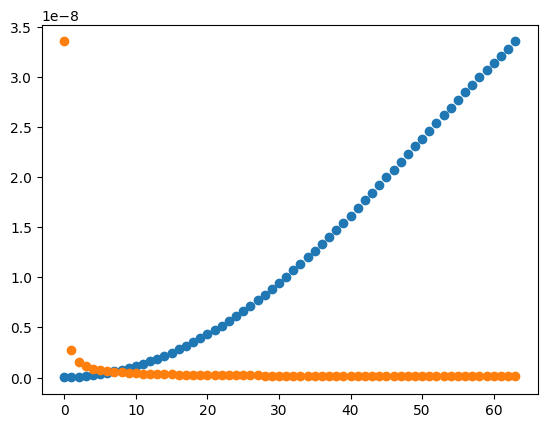

In [94]:
plt.scatter([i for i in range(len(potentiation_conductances))], adjusted_potentiation)
plt.scatter([i for i in range(len(depression_conductances))], adjusted_depression)

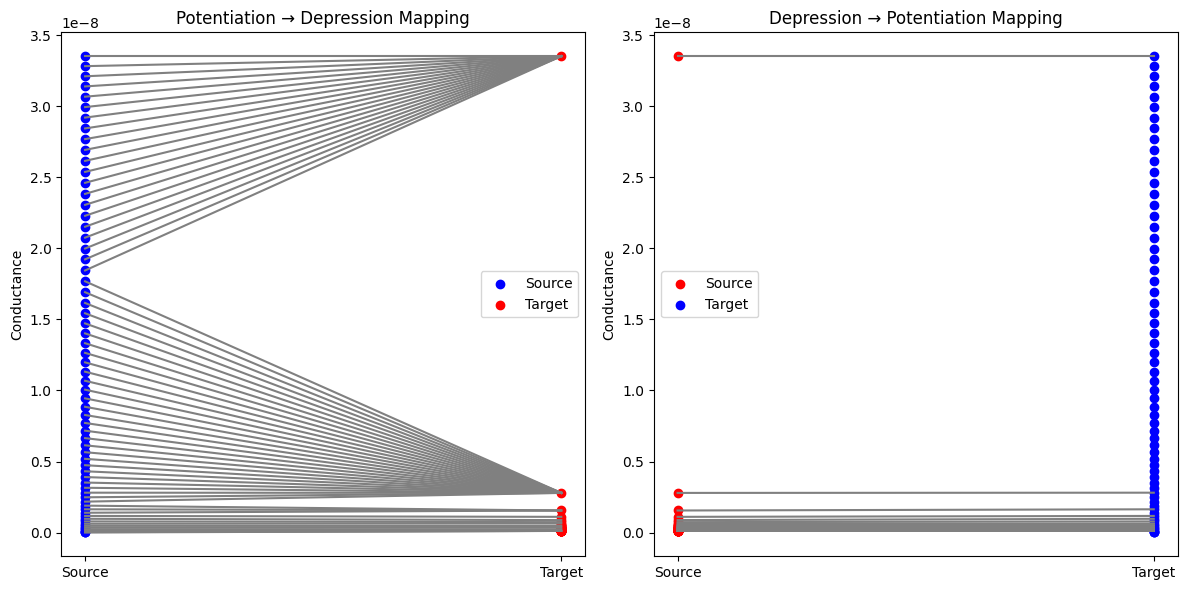

In [95]:
import matplotlib.pyplot as plt
import numpy as np


def map_to_nearest_indices(given_list, reference_list):
    def safe_tensor_conversion(data, dtype=torch.float32):
        if isinstance(data, torch.Tensor):
            return data.clone().detach().to(dtype)  # Clone if it's already a tensor
        return torch.tensor(data, dtype=dtype)  # Convert if it's a list or other type

    given_tensor = safe_tensor_conversion(given_list)
    reference_tensor = safe_tensor_conversion(reference_list)
    indices = torch.abs(reference_tensor.unsqueeze(0) - given_tensor.unsqueeze(-1)).argmin(dim=-1)
            
    return torch.tensor(indices.tolist())

# Example data
# potentiation_conductances = [0.1, 0.2, 0.3, 0.4, 0.5]
# depression_conductances = [0.15, 0.25, 0.35, 0.45, 0.55]

# # Mappings
potentiation_to_depression_mapping = map_to_nearest_indices(adjusted_potentiation, adjusted_depression) # Index-wise mapping
depression_to_potentiation_mapping = map_to_nearest_indices(adjusted_depression, adjusted_potentiation)  # Reverse mapping

# Set positions for plotting
potentiation_x = np.zeros(len(adjusted_potentiation))
depression_x = np.ones(len(adjusted_depression))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # Two subplots side by side

# Function to plot mappings
def plot_mapping(ax, x1, y1, x2, y2, mapping, title, color1, color2):
    ax.scatter(x1, y1, color=color1, label="Source")
    ax.scatter(x2, y2, color=color2, label="Target")

    # Draw mapping lines
    for i, target_idx in enumerate(mapping):
        ax.plot([x1[0], x2[0]], [y1[i], y2[target_idx]], 'gray')

    ax.set_xticks([x1[0], x2[0]])
    ax.set_xticklabels(["Source", "Target"])
    ax.set_ylabel("Conductance")
    ax.set_title(title)
    ax.legend()

# First subplot: Potentiation → Depression
plot_mapping(axs[0], [0] * len(adjusted_potentiation), adjusted_potentiation, 
             [1] * len(adjusted_depression), adjusted_depression, 
             potentiation_to_depression_mapping, 
             "Potentiation → Depression Mapping", "blue", "red")

# Second subplot: Depression → Potentiation
plot_mapping(axs[1], [0] * len(adjusted_depression), adjusted_depression, 
             [1] * len(adjusted_potentiation), adjusted_potentiation, 
             depression_to_potentiation_mapping, 
             "Depression → Potentiation Mapping", "red", "blue")

plt.tight_layout()
plt.show()

In [96]:
x = torch.tensor([0.485], requires_grad=True, device=device)  # starting point
num_steps = 70



In [97]:

# class MLPFitter1:
#     def __init__(self, x, y, hidden_layers=[32, 32], lr=0.01, epochs=5000, device=None):
#         self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
#         x = torch.tensor(x, dtype=torch.float32, device=self.device).view(-1, 1)
#         y = torch.tensor(y, dtype=torch.float32, device=self.device).view(-1, 1)
        
#         self.x_mean, self.x_std = x.mean(), x.std()
#         self.y_mean, self.y_std = y.mean(), y.std()
        
#         x = (x - self.x_mean) / self.x_std
#         y = (y - self.y_mean) / self.y_std
        
#         self.model = self._build_mlp(1, 1, hidden_layers).to(self.device)
#         self.inverse_model = self._build_mlp(1, 1, hidden_layers).to(self.device)
        
#         self.criterion = nn.MSELoss()
#         self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
#         self.inverse_optimizer = optim.Adam(self.inverse_model.parameters(), lr=lr)
#         self.epochs = epochs
        
#         self.x_train, self.y_train = x, y
#         self._train()
#         self._train_inverse()

#     def _build_mlp(self, input_dim, output_dim, hidden_layers):
#         layers = []
#         prev_dim = input_dim
#         for h in hidden_layers:
#             layers.append(nn.Linear(prev_dim, h))
#             layers.append(nn.Tanh())
#             prev_dim = h
#         layers.append(nn.Linear(prev_dim, output_dim))
#         return nn.Sequential(*layers)

#     def _train(self):
#         for _ in range(self.epochs):
#             self.optimizer.zero_grad()
#             y_pred = self.model(self.x_train)
#             loss = self.criterion(y_pred, self.y_train)
#             loss.backward()
#             self.optimizer.step()

#     def _train_inverse(self):
#         for _ in range(self.epochs):
#             self.inverse_optimizer.zero_grad()
#             x_pred = self.inverse_model(self.y_train)
#             loss = self.criterion(x_pred, self.x_train)
#             loss.backward()
#             self.inverse_optimizer.step()

#     def predict(self, x):
#         x_shape = x.shape
#         x_device = x.device  # Preserve device
#         x = ((x - self.x_mean.to(x_device)) / self.x_std.to(x_device)).view((-1, 1))
#         return (self.model(x) * self.y_std.to(x_device) + self.y_mean.to(x_device)).view(x_shape)

#     def inverse(self, y):
#         y_shape = y.shape
#         y_device = y.device  # Preserve device
#         y = ((y - self.y_mean.to(y_device)) / self.y_std.to(y_device)).view((-1, 1))
#         return (self.inverse_model(y) * self.x_std.to(y_device) + self.x_mean.to(y_device)).view(y_shape)

#     def evaluate(self):
#         y_pred = self.model(self.x_train) * self.y_std + self.y_mean
#         x_pred = self.inverse_model(self.y_train) * self.x_std + self.x_mean
        
#         forward_mse = mean_squared_error(self.y_train.cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy(), y_pred.cpu().detach().numpy())
#         forward_r2 = r2_score(self.y_train.cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy(), y_pred.cpu().detach().numpy())
        
#         inverse_mse = mean_squared_error(self.x_train.cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy(), x_pred.cpu().detach().numpy())
#         inverse_r2 = r2_score(self.x_train.cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy(), x_pred.cpu().detach().numpy())
        
#         print(f"Forward Mapping (x -> y):\n  MSE: {forward_mse:.6f}, R² Score: {forward_r2:.6f}")
#         print(f"Inverse Mapping (y -> x):\n  MSE: {inverse_mse:.6f}, R² Score: {inverse_r2:.6f}")

#     def plot(self):
#         x_vals = self.x_train.cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy()
#         y_vals = self.y_train.cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy()
#         y_preds = self.model(self.x_train).cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy()
#         x_preds = self.inverse_model(self.y_train).cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy()
        
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
#         axes[0].scatter(x_vals, y_vals, label="Data", color="blue")
#         axes[0].plot(x_vals, y_preds, label="MLP Fit", color="red")
#         axes[0].set_title("Forward Mapping (x -> y)")
#         axes[0].legend()
        
#         axes[1].scatter(y_vals, x_vals, label="Data", color="blue")
#         axes[1].plot(y_vals, x_preds, label="MLP Inverse Fit", color="red")
#         axes[1].set_title("Inverse Mapping (y -> x)")
#         axes[1].legend()
        
#         plt.show()


    
#     def plot_residuals_probplot(self):
#         # Compute residuals
#         y_true = self.y_train.cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy()
#         y_pred = self.model(self.x_train).cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy()
#         forward_residuals = y_true - y_pred  # Residuals for forward mapping

#         x_true = self.x_train.cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy()
#         x_pred = self.inverse_model(self.y_train).cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy()
#         inverse_residuals = x_true - x_pred  # Residuals for inverse mapping

#         fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#         # Q-Q plot for forward residuals
#         stats.probplot(forward_residuals.flatten(), dist="norm", plot=axes[0])
#         axes[0].set_title("Q-Q Plot: Forward Residuals (x -> y)")

#         # Q-Q plot for inverse residuals
#         stats.probplot(inverse_residuals.flatten(), dist="norm", plot=axes[1])
#         axes[1].set_title("Q-Q Plot: Inverse Residuals (y -> x)")

#         plt.tight_layout()
#         plt.show()


        
#     def plot_residuals(self):
#         x_vals = self.x_train.cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy()
#         y_vals = self.y_train.cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy()
#         y_preds = self.model(self.x_train).cpu().detach().numpy() * self.y_std.cpu().detach().numpy() + self.y_mean.cpu().detach().numpy()
#         x_preds = self.inverse_model(self.y_train).cpu().detach().numpy() * self.x_std.cpu().detach().numpy() + self.x_mean.cpu().detach().numpy()

#         forward_residuals = y_vals - y_preds
#         inverse_residuals = x_vals - x_preds

#         fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#         # Histogram of residuals
#         axes[0, 0].hist(forward_residuals, bins=30, color='blue', alpha=0.7)
#         axes[0, 0].set_title("Forward Residuals Histogram (x -> y)")
#         axes[0, 0].set_xlabel("Residual Value")
#         axes[0, 0].set_ylabel("Frequency")

#         axes[0, 1].hist(inverse_residuals, bins=30, color='red', alpha=0.7)
#         axes[0, 1].set_title("Inverse Residuals Histogram (y -> x)")
#         axes[0, 1].set_xlabel("Residual Value")
#         axes[0, 1].set_ylabel("Frequency")

#         # Scatter plot of residuals
#         axes[1, 0].scatter(x_vals, forward_residuals, color='blue', alpha=0.5)
#         axes[1, 0].axhline(y=0, color='black', linestyle='dashed')
#         axes[1, 0].set_title("Forward Residuals (x -> y)")
#         axes[1, 0].set_xlabel("x")
#         axes[1, 0].set_ylabel("Residual")

#         axes[1, 1].scatter(y_vals, inverse_residuals, color='red', alpha=0.5)
#         axes[1, 1].axhline(y=0, color='black', linestyle='dashed')
#         axes[1, 1].set_title("Inverse Residuals (y -> x)")
#         axes[1, 1].set_xlabel("y")
#         axes[1, 1].set_ylabel("Residual")

#         plt.tight_layout()
#         plt.show()

In [98]:
# class NNApproximationBasedOptimizer(Optimizer):
#     def __init__(self, params, potentiation:list, depression:list, lr=0.01, tau=0.0):

#         defaults = {"potentiation":potentiation, "depression":depression, "lr": lr, "tau":tau}
#         super().__init__(params, defaults)

#         self.device = self.param_groups[0]['params'][0].device

#         self.potentiation_approximator = MLPFitter1(list(range(len(potentiation))), potentiation, device=self.device)
#         self.potentiation_approximator.evaluate()
#         self.depression_approximator = MLPFitter1(list(range(len(depression))), depression, device=self.device)
#         self.depression_approximator.evaluate()

#         self.min_conductance = torch.tensor(max(min(potentiation), min(depression)), device=device)
#         self.max_conductance = torch.tensor(min(max(potentiation), max(depression)), device=device)

#         self.potentiation = {
#             "max" : self.get_state_from_conductance(self.max_conductance),
#             "min" : self.get_state_from_conductance(self.min_conductance)
#         }
#         self.depression = {
#             "max": self.get_state_from_conductance(self.max_conductance, False),
#             "min":self.get_state_from_conductance(self.min_conductance, False)
#         }

#         self.min_weight, self.max_weight = -0.5, 0.5


#         for group in self.param_groups:
#             for p in group['params']:
#                 if p.requires_grad:
#                     self.state[p] = {
#                         "state": self.get_state_from_conductance(self.map_weights_to_conductances(p.data)), 
#                         "flag": torch.ones_like(p.data, dtype=torch.bool) 
#                     }

#     def step(self):
        
#         for group in self.param_groups:
#             lr = group['lr']
#             tau = group['tau']
#             for p in group['params']:

#                 if p.grad is None:
#                     continue

#                 grad = p.grad
#                 state = self.state[p]['state']
#                 flags = self.state[p]['flag']

#                 potentiation_to_decrease_mask = ((grad > tau) & (flags)).bool()
#                 potentiation_to_increase_mask = ((grad < -tau) & (flags.bool())).bool()

#                 depression_to_decrease_mask = ((grad > tau) & (~flags)).bool()
#                 depression_to_increase_mask = ((grad < -tau) & (~flags.bool())).bool()

#                 state[potentiation_to_increase_mask] -= lr * grad[potentiation_to_increase_mask]
#                 state[depression_to_decrease_mask] += lr * grad[depression_to_decrease_mask]

#                 if potentiation_to_decrease_mask.any():
#                     conductance = self.map_weights_to_conductances(p.data[potentiation_to_decrease_mask])
#                     state[potentiation_to_decrease_mask] = self.get_state_from_conductance(conductance, flag=False) + lr * grad[potentiation_to_decrease_mask]
#                     flags[potentiation_to_decrease_mask] = False

#                 if depression_to_increase_mask.any():
#                     conductance = self.map_conductances_to_weights(p.data[depression_to_increase_mask])
#                     state[depression_to_increase_mask] = self.get_state_from_conductance(conductance) - lr * grad[depression_to_increase_mask]
#                     flags[depression_to_increase_mask] = True

#                 conductance = torch.where(
#                     flags.bool(),
#                     self.get_conductance_from_state(state.clamp(self.potentiation['min'], self.potentiation['max'])),
#                     self.get_conductance_from_state(state.clamp(self.depression['min'], self.depression['max']), False)
#                 )

#                 p.data.copy_(self.map_conductances_to_weights(conductance))






    
#     def get_conductance_from_state(self, state, flag=True):
#         if flag:
#             return self.potentiation_approximator.predict(state)
#         return self.depression_approximator.predict(state)

#     def get_state_from_conductance(self, conductance, flag=True):
#         if flag:
#             return self.potentiation_approximator.inverse(conductance)
#         return self.depression_approximator.inverse(conductance)


#     def map_weights_to_conductances(self, weight):

#         normalized_weight = (weight - self.min_weight) / (self.max_weight - self.min_weight)

#         normalized_conductance = normalized_weight

#         return normalized_conductance * (self.max_conductance - self.min_conductance) + self.min_conductance
    
#     def map_conductances_to_weights(self, conductance):
#         normalized_conductance = (conductance - self.min_conductance) / (self.max_conductance - self.min_conductance)

#         normalized_weight = normalized_conductance

#         return normalized_weight * (self.max_weight - self.min_weight) + self.min_weight
    

        

        




In [99]:

# Lists to store x and y values for plotting
x_values, x_true_values = [], []
y_values, y_true_values = [], []

# Function to implement
def f(x):
    return (x)**2

# Initialize Optimizer
# optimizer = DiscreteStateOptimizer([x], finite_set, tau=0.05)
optimizer = RRAMOptimizer([x], potentiation=adjusted_potentiation, depression=adjusted_depression, tau=0.05)
# optimizer = ContinuousOptimizer([x], 
#                                 potentiation=torch.tensor(adjusted_potentiation).to(device), 
#                                 depression=torch.tensor(adjusted_depression).to(device), 
#                                 potentiation_degree=5,
#                                 depression_degree=3,
#                                 tau=0.05)

# optimizer = NNApproximationBasedOptimizer([x], potentiation=adjusted_potentiation, depression=adjusted_depression, lr=1.0)


In [100]:
a = torch.tensor(True, dtype=torch.bool, device=device)
b = torch.tensor(True, dtype=torch.bool, device=device)
print(a, b, a&b)

tensor(True, device='cuda:0') tensor(True, device='cuda:0') tensor(True, device='cuda:0')


In [101]:
# Optimization Loop
for _ in range(num_steps):
    optimizer.zero_grad()  # Clear previous gradients
    y = f(x)  # Calculate y = x^2

    # Store current x and y for plotting
    x_values.append(x.item())
    y_values.append(y.item())
    y.backward()  # Compute the gradient of y with respect to x
    optimizer.step()  # Perform the optimization step

In [102]:
# x_dense = torch.linspace(optimizer.min_conductance, optimizer.max_conductance, steps=1000)
# y_pred = optimizer.potentiation_model.predict(x_dense)

# # Plot original points and fitted curve
# plt.scatter(potentiation_conductances, optimizer.potentiation_g_by_g0.cpu(), label="Original Data", color="blue")
# plt.plot(x_dense.cpu(), y_pred.cpu(), label="Fitted Curve", color="red")
# plt.legend()
# plt.show()

In [103]:
# x_dense = torch.linspace(optimizer.max_conductance, optimizer.min_conductance, steps=1000)
# y_pred = optimizer.depression_model.predict(x_dense)

# # Plot original points and fitted curve
# plt.scatter(depression_conductances, optimizer.depression_g_by_g0.cpu(), label="Original Data", color="blue")
# plt.plot(x_dense.cpu(), y_pred.cpu(), label="Fitted Curve", color="red")
# plt.legend()
# plt.show()

In [104]:
optimizer.potentiation, optimizer.depression

(tensor([-1.0000, -0.9987, -0.9960, -0.9919, -0.9865, -0.9800, -0.9723, -0.9635,
         -0.9536, -0.9426, -0.9306, -0.9172, -0.9027, -0.8874, -0.8705, -0.8524,
         -0.8330, -0.8123, -0.7904, -0.7674, -0.7431, -0.7176, -0.6909, -0.6631,
         -0.6340, -0.6039, -0.5726, -0.5403, -0.5068, -0.4724, -0.4369, -0.4005,
         -0.3632, -0.3250, -0.2858, -0.2459, -0.2053, -0.1641, -0.1221, -0.0796,
         -0.0364,  0.0088,  0.0546,  0.1001,  0.1468,  0.1922,  0.2379,  0.2837,
          0.3297,  0.3757,  0.4216,  0.4681,  0.5138,  0.5603,  0.6064,  0.6516,
          0.6965,  0.7420,  0.7861,  0.8298,  0.8729,  0.9155,  0.9580,  1.0000],
        device='cuda:0'),
 tensor([ 1.0000, -0.8339, -0.9078, -0.9344, -0.9481, -0.9566, -0.9625, -0.9668,
         -0.9701, -0.9727, -0.9749, -0.9766, -0.9781, -0.9794, -0.9806, -0.9815,
         -0.9824, -0.9832, -0.9839, -0.9845, -0.9851, -0.9857, -0.9861, -0.9866,
         -0.9870, -0.9874, -0.9878, -0.9881, -0.9884, -0.9887, -0.9890, -0.9892,
 

In [105]:
# optimizer.min_conductance, min(adjusted_potentiation)

In [106]:
# optimizer.potentiation_approximator.inverse(torch.tensor(min(adjusted_potentiation), device=device))

In [107]:
# optimizer.potentiation_approximator.plot()

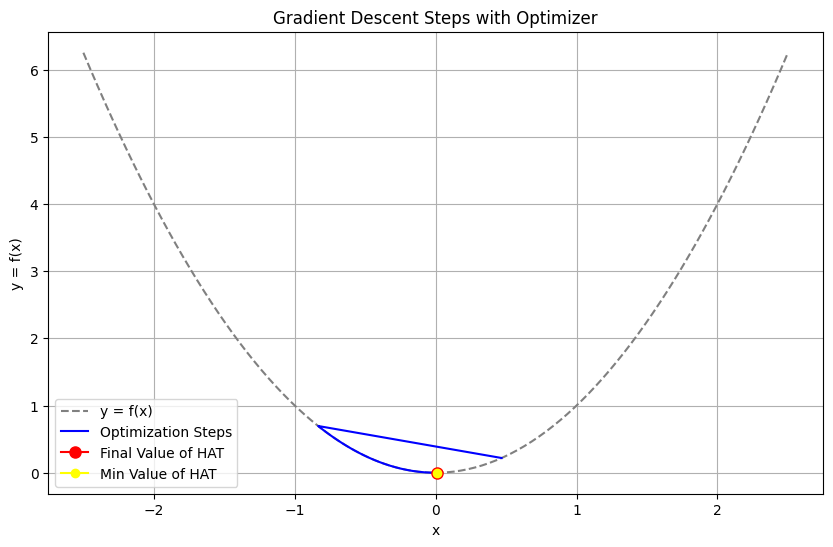

In [108]:

x_curve = np.linspace(-2.5, 2.5, 100)  # Define the range for x
y_curve = f(x_curve)   # Calculate y values for the function

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_curve, y_curve, label="y = f(x)", color='gray', linestyle='--')  # Plot the function
plt.plot(x_values, y_values, color='b', label="Optimization Steps")  # Plot the optimization steps

# Mark the final value with a red dot
plt.plot(x_values[-1], y_values[-1], marker='o', color='red', markersize=8, label="Final Value of HAT")
plt.plot(x_values[np.argmin(y_values)], y_values[np.argmin(y_values)] , marker='o', color='yellow', markersize=6, label="Min Value of HAT")

plt.xlabel("x")
plt.ylabel("y = f(x)")
plt.title("Gradient Descent Steps with Optimizer")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
optimizer.state

defaultdict(dict,
            {tensor([0.0088], device='cuda:0', requires_grad=True): {'state_idx': tensor([41], device='cuda:0'),
              'flags': tensor([1], device='cuda:0')}})

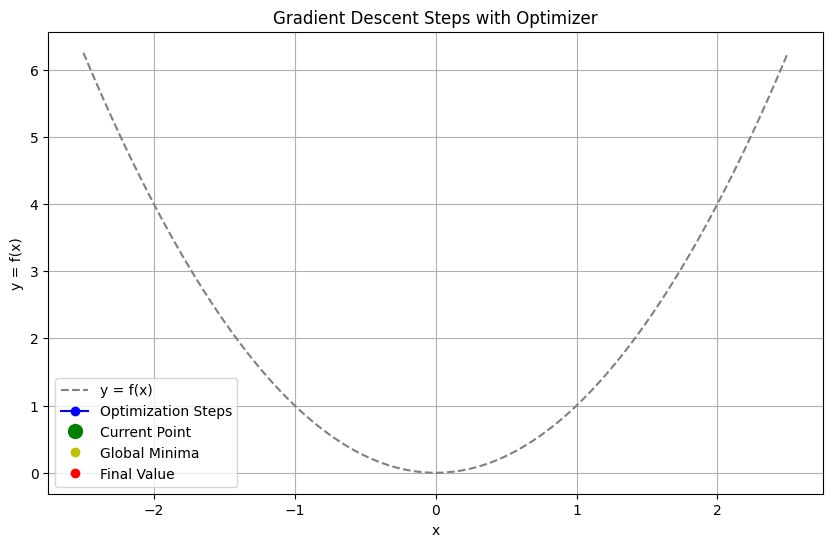

In [110]:

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_curve, y_curve, label="y = f(x)", color='gray', linestyle='--')
ax.set_xlabel("x")
ax.set_ylabel("y = f(x)")
ax.set_title("Gradient Descent Steps with Optimizer")
ax.grid(True)

# # Initialize the line for the optimization steps
line, = ax.plot([], [], color='b', marker='o', label="Optimization Steps")
# final_point, = ax.plot([], [], 'ro', markersize=8, label="Final Value of HAT")
# min_point, = ax.plot([], [], 'yo', markersize=6, label="Min Value of HAT")

# Initialize plots for each color category
past_points, = ax.plot([], [], 'bo', label="_nolegend_")  # Blue for past points
current_point, = ax.plot([], [], 'go', label="Current Point", markersize = 10)  # Green for current point
min_point, = ax.plot([], [], 'yo', label="Global Minima")  # Yellow for minimum point
final_point, = ax.plot([], [], 'ro', label="Final Value")  # Red for final point

# Function to initialize the animation
def init():
    line.set_data([], [])
    current_point.set_data([], [])
    min_point.set_data([], [])
    final_point.set_data([], [])
    return line, current_point, min_point, final_point

# Animation function to update the plot in each frame
def animate(i):
    # Update the line with all points up to the current point
    line.set_data(x_values[:i+1], y_values[:i+1])
    
    # Update the green point for the current point
    current_point.set_data([x_values[i]], [y_values[i]])
    
    # Set the yellow point for the minimum point if the current frame has passed it
    min_index = np.argmin(y_values)
    if i >= min_index:
        min_point.set_data([x_values[min_index]], [y_values[min_index]])
    
    # Set the red point for the final point in the last frame
    if i == len(x_values) - 1:
        final_point.set_data([x_values[-1]], [y_values[-1]])
    
    return line, current_point, min_point, final_point

# Create the animation
ani = FuncAnimation(fig, animate, frames=len(x_values), init_func=init, interval=500, blit=True)

# Show the plot
plt.legend()
plt.show()

from IPython.display import HTML
HTML(ani.to_jshtml())

In [111]:
(f"Overall minima = {x_values[np.argmin(y_values)]}", 
 f"Final Value after optimization = {x_values[-1]}")

('Overall minima = 0.008771507069468498',
 'Final Value after optimization = 0.008771507069468498')